# Demo - End-to-End Music Context Inference

Takes one raw MP3 and runs the complete pipeline:

**audio -> log-mel + chroma -> segmentation -> structure graph -> GNN + BERT fusion -> predicted tags**

Requires a trained Task 3 checkpoint:

```
python scripts/preprocess.py
python -m src.train --task 3 --run-name task3_cross_attention
```

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.audio_features import FeatureExtractor, load_audio, estimate_chords
from src.bert_encoder import build_tokenizer
from src.dataset import load_vocabulary
from src.graph_builder import GraphConfig, build_track_graph, graph_summary
from src.train import build_model
from src.utils import get_device, load_checkpoint, load_config, resolve

cfg = load_config(ROOT / "config.yaml")
processed, raw = resolve(cfg, "processed_dir"), resolve(cfg, "raw_dir")
device = get_device(cfg["device"])
label_tags, _ = load_vocabulary(processed)
plt.rcParams["figure.dpi"] = 110
print("device:", device, "| tags:", len(label_tags))

device: cuda | tags: 50


## 1. Pick a clip from the test split

In [2]:
manifest = pd.read_csv(processed / "manifest.csv")
test = manifest[manifest.split == "test"].reset_index(drop=True)

CLIP_INDEX = 0                       # change to inspect a different clip
row = test.iloc[CLIP_INDEX]
mp3_path = raw / "audio" / row["mp3_path"]

print(f"clip_id : {row['clip_id']}")
print(f"title   : {row['title']}")
print(f"artist  : {row['artist']}")
print(f"album   : {row['album']}")
print(f"file    : {mp3_path}")
print()
print("context text given to BERT:")
print(" ", row["context_text"][:300])
print()
true_tags = [t for t in label_tags if row[t] == 1]
print("ground-truth tags:", ", ".join(true_tags) if true_tags else "(none)")

clip_id : 2
title   : BWV54 - I Aria
artist  : American Bach Soloists
album   : J.S. Bach Solo Cantatas
file    : E:\425 final project\gnn-bert-music-context\data\raw\mtat\audio\f\american_bach_soloists-j_s__bach_solo_cantatas-01-bwv54__i_aria-30-59.mp3

context text given to BERT:
  The track is titled 'BWV54 - I Aria' by American Bach Soloists, from the album 'J.S. Bach Solo Cantatas'.

ground-truth tags: classical, string, violin, opera


## 2. Audio -> features

waveform (642185,) (29.1s) | mel (128, 1255) | chroma (12, 1255)


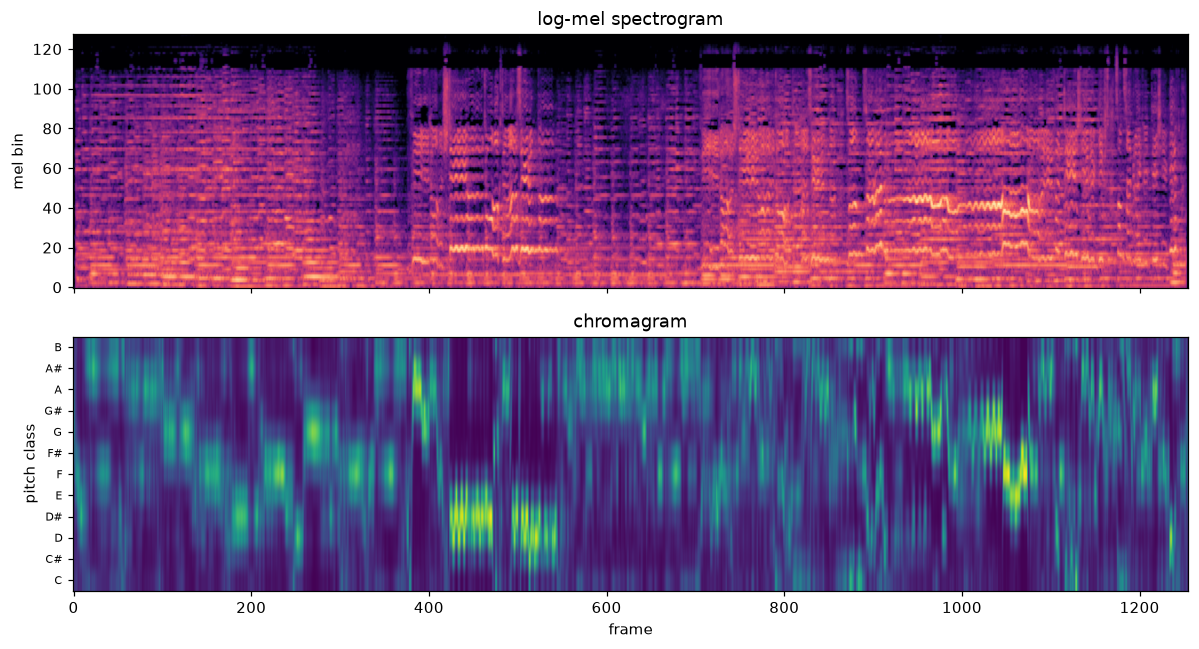

estimated chord sequence: F#:min -> F:min -> B:maj -> A#:maj -> A#:min -> A#:maj -> A:maj -> D:min -> F:maj -> D:min -> F:maj -> F#:min


In [3]:
extractor = FeatureExtractor(
    sample_rate=cfg["audio"]["sample_rate"], n_fft=cfg["audio"]["n_fft"],
    hop_length=cfg["audio"]["hop_length"], n_mels=cfg["audio"]["n_mels"],
    n_chroma=cfg["audio"]["n_chroma"], fmin=cfg["audio"]["fmin"], fmax=cfg["audio"]["fmax"],
    device="cpu",
)
waveform = load_audio(mp3_path, cfg["audio"]["sample_rate"])
log_mel, chroma = extractor.log_mel(waveform), extractor.chroma(waveform)
print(f"waveform {tuple(waveform.shape)} ({waveform.shape[0]/cfg['audio']['sample_rate']:.1f}s)"
      f" | mel {tuple(log_mel.shape)} | chroma {tuple(chroma.shape)}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].imshow(log_mel.numpy(), aspect="auto", origin="lower", cmap="magma")
axes[0].set_ylabel("mel bin"); axes[0].set_title("log-mel spectrogram")
axes[1].imshow(chroma.numpy(), aspect="auto", origin="lower", cmap="viridis")
axes[1].set_ylabel("pitch class"); axes[1].set_xlabel("frame"); axes[1].set_title("chromagram")
axes[1].set_yticks(range(12))
axes[1].set_yticklabels(["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"], fontsize=7)
plt.tight_layout(); plt.show()

print("estimated chord sequence:", " -> ".join(estimate_chords(chroma)[:12]))

## 3. Build the structure graph

In [4]:
graph = build_track_graph(waveform, extractor, cfg["audio"], GraphConfig(**dict(cfg["graph"])))
print(json.dumps(graph_summary(graph), indent=2))

{
  "num_nodes": 34,
  "num_segments": 10,
  "num_chords": 24,
  "num_edges": 544,
  "edges_by_type": {
    "temporal": 52,
    "similarity": 80,
    "chord_transition": 158,
    "membership": 254
  },
  "feature_dim": 280
}


## 4. Load the trained fusion model and predict

In [5]:
from torch_geometric.loader import DataLoader as GeoDataLoader

RUN_NAME = "task3_cross_attention"
checkpoint = resolve(cfg, "results_dir") / "checkpoints" / f"{RUN_NAME}.pt"

tokenizer = build_tokenizer(cfg["text"]["model_name"])
encoded = tokenizer(row["context_text"], truncation=True, padding="max_length",
                    max_length=cfg["text"]["max_length"], return_tensors="pt")
graph.input_ids = encoded["input_ids"]
graph.attention_mask = encoded["attention_mask"]
graph.y = torch.zeros(1, len(label_tags))

model = build_model(cfg, "3", len(label_tags), graph.x.shape[1]).to(device)
meta = load_checkpoint(checkpoint, model, device)
model.eval()
print(f"loaded {RUN_NAME} (epoch {meta.get('epoch')}, {meta.get('monitor')}={meta.get('score'):.4f})")

batch = next(iter(GeoDataLoader([graph], batch_size=1))).to(device)
with torch.no_grad():
    outputs = model(batch)
probabilities = torch.sigmoid(outputs["tag_logits"]).cpu().numpy()[0]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


loaded task3_cross_attention (epoch 3, val_macro_f1=0.3789)


In [6]:
metrics = json.loads((resolve(cfg, "results_dir") / "metrics.json").read_text())
thresholds = np.asarray(metrics[RUN_NAME]["thresholds"]) if RUN_NAME in metrics else np.full(len(label_tags), 0.5)

predictions = pd.DataFrame({
    "tag": label_tags,
    "probability": probabilities,
    "threshold": thresholds,
    "predicted": probabilities >= thresholds,
    "ground_truth": [row[t] == 1 for t in label_tags],
}).sort_values("probability", ascending=False)

print("Top 12 predictions\n")
print(predictions.head(12).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

hits = predictions[predictions.predicted & predictions.ground_truth]["tag"].tolist()
misses = predictions[~predictions.predicted & predictions.ground_truth]["tag"].tolist()
false_alarms = predictions[predictions.predicted & ~predictions.ground_truth]["tag"].tolist()
print(f"\ncorrect  : {hits}")
print(f"missed   : {misses}")
print(f"spurious : {false_alarms}")

Top 12 predictions

         tag  probability  threshold  predicted  ground_truth
       opera        0.956      0.750       True          True
      violin        0.918      0.650       True          True
      string        0.907      0.700       True          True
   classical        0.902      0.700       True          True
      female        0.738      0.650       True         False
female vocal        0.707      0.850      False         False
   orchestra        0.692      0.100       True         False
      singer        0.585      0.700      False         False
 harpsichord        0.576      0.600      False         False
       vocal        0.575      0.450       True         False
        soft        0.499      0.850      False         False
       flute        0.386      0.700      False         False

correct  : ['opera', 'violin', 'string', 'classical']
missed   : []
spurious : ['female', 'orchestra', 'vocal']


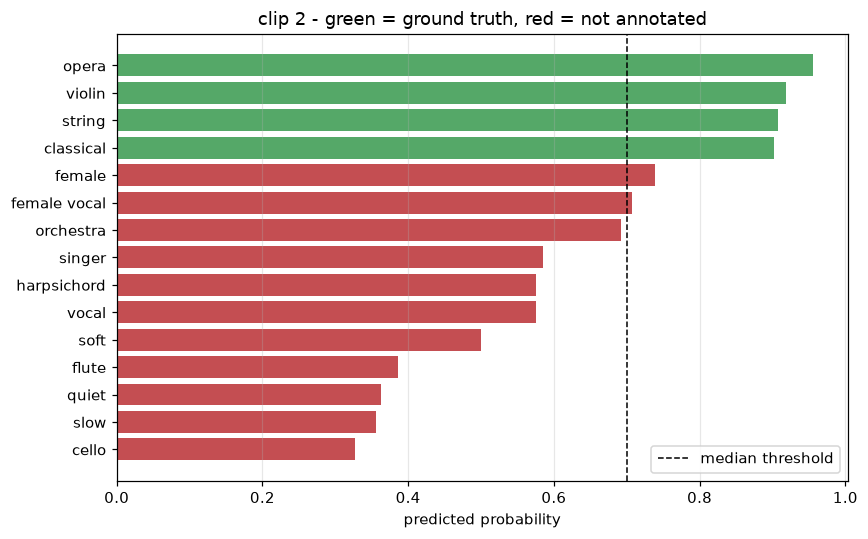

In [7]:
top = predictions.head(15).iloc[::-1]
colours = ["#55A868" if t else "#C44E52" for t in top.ground_truth]
plt.figure(figsize=(8, 5))
plt.barh(top.tag, top.probability, color=colours)
plt.axvline(float(np.median(thresholds)), ls="--", c="k", lw=1, label="median threshold")
plt.xlabel("predicted probability")
plt.title(f"clip {row['clip_id']} - green = ground truth, red = not annotated")
plt.legend(); plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

## 5. What did the graph attend to in the text?

Cross-attention gives one distribution over BERT tokens per clip, so we can read
off which words the track's structure aligned with.

Highest-attention tokens:
                 the  0.2500
            soloists  0.2500
                bach  0.2500
                   .  0.1250
               track  0.1250
                bach  0.0000
                   j  0.0000
                   .  0.0000
            american  0.0000
                   ,  0.0000
             cantata  0.0000
                   -  0.0000


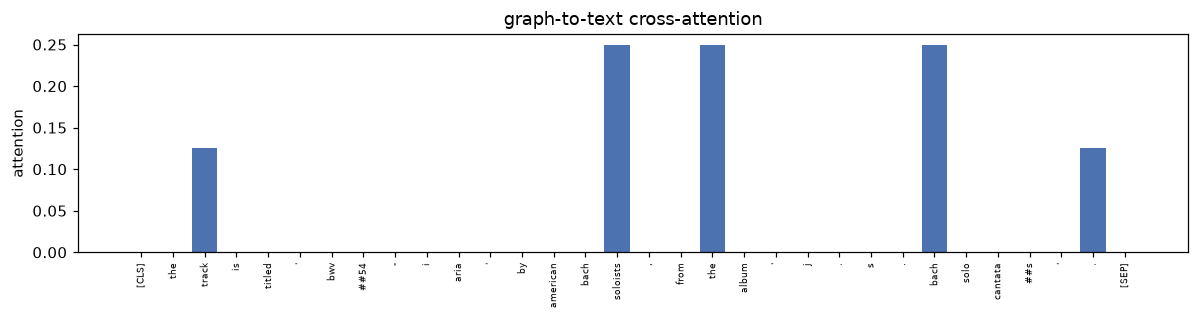

In [8]:
if "text_attention" in outputs:
    weights = outputs["text_attention"][0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
    keep = encoded["attention_mask"][0].numpy() == 1
    tokens = [t for t, k in zip(tokens, keep) if k]
    weights = weights[: len(tokens)]

    order = np.argsort(weights)[::-1][:12]
    print("Highest-attention tokens:")
    for i in order:
        print(f"  {tokens[i]:>18s}  {weights[i]:.4f}")

    plt.figure(figsize=(11, 3))
    plt.bar(range(len(tokens)), weights, color="#4C72B0")
    plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=6)
    plt.ylabel("attention"); plt.title("graph-to-text cross-attention")
    plt.tight_layout(); plt.show()
else:
    print("This checkpoint does not use cross-attention fusion.")

## 6. Summary

One MP3 in, a music structure graph and a ranked set of context tags out, with
the text tokens the graph attended to. Swap `CLIP_INDEX` to inspect other clips,
or point `mp3_path` at any audio file to run the pipeline on your own music.